# 1️⃣ Import Libraries

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import joblib
import gc, time
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_squared_error, mean_absolute_error
import lightgbm as lgb


-----------------------------------------------------
# 2️⃣ Load Dataset (use Feather for low memory)

In [2]:
print("🔹 Loading Feather dataset...")
df = pd.read_feather("dataset/dimred_df.feather")

# Keep essential columns
df = df[["id", "date_id", "PC1", "PC2", "value"]]


🔹 Loading Feather dataset...


# Convert to lightweight dtypes

In [3]:
df = df.astype({
    "id": "category",
    "date_id": "int32",
    "PC1": "float32",
    "PC2": "float32",
    "value": "float32"
})


# 3️⃣ Data Pre-processing

In [4]:
print("\n🔍 Checking data quality...")
print(df.info())

print("\nNull values per column:\n", df.isnull().sum())
print("\nDuplicate rows:", df.duplicated().sum())

df = df.dropna().drop_duplicates().reset_index(drop=True)
gc.collect()



🔍 Checking data quality...
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 47735397 entries, 0 to 47735396
Data columns (total 5 columns):
 #   Column   Dtype   
---  ------   -----   
 0   id       category
 1   date_id  int32   
 2   PC1      float32 
 3   PC2      float32 
 4   value    float32 
dtypes: category(1), float32(3), int32(1)
memory usage: 820.7 MB
None

Null values per column:
 id         0
date_id    0
PC1        0
PC2        0
value      0
dtype: int64

Duplicate rows: 0


95

# 4️⃣ Feature Engineering

In [5]:
df["day_sin"]   = np.sin(2 * np.pi * df["date_id"] / 7)
df["day_cos"]   = np.cos(2 * np.pi * df["date_id"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["date_id"] / 30.5)
df["month_cos"] = np.cos(2 * np.pi * df["date_id"] / 30.5)

features = ["date_id", "PC1", "PC2", "day_sin", "day_cos", "month_sin", "month_cos"]
target   = "value"

# 5️⃣ Train / Test Split

In [6]:
max_date  = df["date_id"].max()
train_cut = int(max_date * 0.8)

train_df = df[df["date_id"] <= train_cut]
test_df  = df[df["date_id"] > train_cut]

X_train, y_train = train_df[features], train_df[target]
X_test,  y_test  = test_df[features],  test_df[target]

print("\nTrain shape:", X_train.shape, " | Test shape:", X_test.shape)



Train shape: (35743638, 7)  | Test shape: (11991759, 7)


# 6️⃣ Feature Scaling

In [7]:
scaler = StandardScaler()
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)
joblib.dump(scaler, "scaler.joblib")


['scaler.joblib']

# 7️⃣ Model Training

In [8]:
def evaluate_model(model, X_tr, y_tr, X_te, y_te):
    start = time.time()
    model.fit(X_tr, y_tr)
    preds = model.predict(X_te)
    rmse = np.sqrt(mean_squared_error(y_te, preds))
    mae  = mean_absolute_error(y_te, preds)
    runtime = time.time() - start
    return rmse, mae, runtime, preds

print("\n🚀 Training LightGBM model...")
lgbm = lgb.LGBMRegressor(
    n_estimators=300,
    learning_rate=0.05,
    num_leaves=31,
    subsample=0.8,
    colsample_bytree=0.8,
    random_state=42
)

rmse, mae, runtime, preds = evaluate_model(lgbm, X_train, y_train, X_test, y_test)

print(f"✅ LightGBM Results -> RMSE: {rmse:.4f} | MAE: {mae:.4f} | Time: {runtime:.2f}s")



🚀 Training LightGBM model...
[LightGBM] [Info] Auto-choosing row-wise multi-threading, the overhead of testing was 0.261146 seconds.
You can set `force_row_wise=true` to remove the overhead.
And if memory is not enough, you can set `force_col_wise=true`.
[LightGBM] [Info] Total Bins 1783
[LightGBM] [Info] Number of data points in the train set: 35743638, number of used features: 7
[LightGBM] [Info] Start training from score 1.463236
✅ LightGBM Results -> RMSE: 3.3029 | MAE: 1.4919 | Time: 175.74s


# 8️⃣ Save Model

In [9]:
joblib.dump(lgbm, "LightGBM_model.joblib")
print("💾 Model saved as LightGBM_model.joblib")

💾 Model saved as LightGBM_model.joblib


# 9️⃣ Visualization

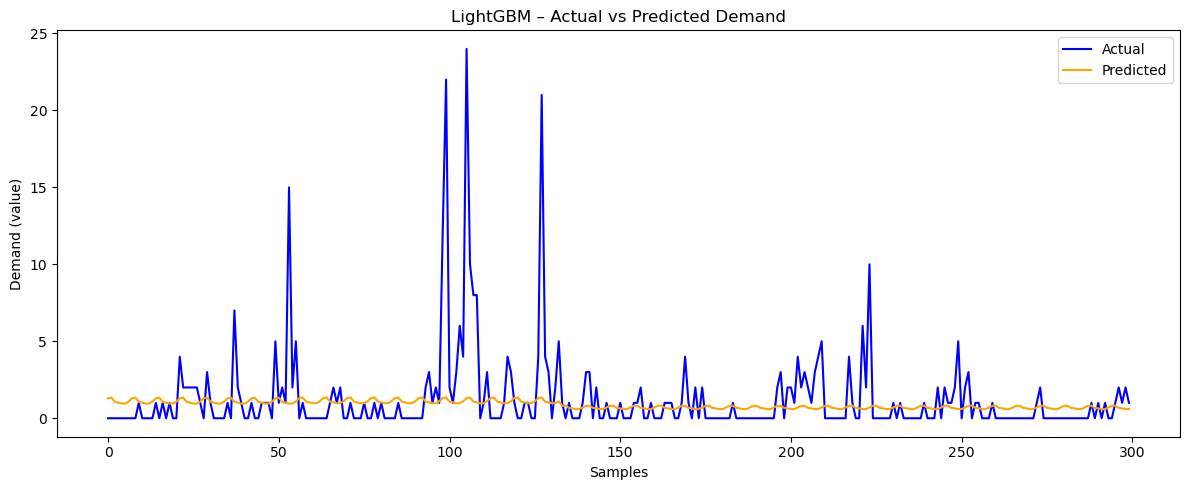

🎯 Forecasting complete!


In [10]:
plt.figure(figsize=(12,5))
plt.plot(y_test.values[:300], label="Actual", color="blue")
plt.plot(preds[:300], label="Predicted", color="orange")
plt.title("LightGBM – Actual vs Predicted Demand")
plt.xlabel("Samples")
plt.ylabel("Demand (value)")
plt.legend()
plt.tight_layout()
plt.show()

print("🎯 Forecasting complete!")

In [13]:
# ==========================================================
# DEMAND FORECASTING – PREDICTION SCRIPT
# ==========================================================

# 1️⃣ Import Libraries
import pandas as pd
import numpy as np
import joblib

# ----------------------------------------------------------
# 2️⃣ Load Saved Model and Scaler
print("🔹 Loading trained model...")

model = joblib.load("LightGBM_model.joblib")
scaler = joblib.load("scaler.joblib")

# ----------------------------------------------------------
# 3️⃣ Load Dataset
print("🔹 Loading dataset...")

df = pd.read_feather("dataset/dimred_df.feather")

# Keep required columns
df = df[["id", "date_id", "PC1", "PC2", "value"]]

df = df.astype({
    "id": "category",
    "date_id": "int32",
    "PC1": "float32",
    "PC2": "float32",
    "value": "float32"
})

# ----------------------------------------------------------
# 4️⃣ Feature Engineering (same as training)
print("🔹 Creating features...")

df["day_sin"] = np.sin(2 * np.pi * df["date_id"] / 7)
df["day_cos"] = np.cos(2 * np.pi * df["date_id"] / 7)
df["month_sin"] = np.sin(2 * np.pi * df["date_id"] / 30.5)
df["month_cos"] = np.cos(2 * np.pi * df["date_id"] / 30.5)

features = ["date_id","PC1","PC2","day_sin","day_cos","month_sin","month_cos"]

X = df[features]

# ----------------------------------------------------------
# 5️⃣ Scale Features
print("🔹 Scaling features...")

X_scaled = scaler.transform(X)

# ----------------------------------------------------------
# 6️⃣ Predict Demand
print("🚀 Predicting demand...")

predictions = model.predict(X)

df["Predicted_Demand"] = predictions

# ----------------------------------------------------------
# 7️⃣ Save Predictions
output_file = "predicted_demand.csv"

df[["id","date_id","value","Predicted_Demand"]].to_csv(output_file, index=False)

print("✅ Predictions saved to:", output_file)

# ----------------------------------------------------------
# 8️⃣ Show Sample Results
print("\nSample Predictions:")
print(df[["id","date_id","value","Predicted_Demand"]].head(10))

🔹 Loading trained model...
🔹 Loading dataset...
🔹 Creating features...
🔹 Scaling features...
🚀 Predicting demand...
✅ Predictions saved to: predicted_demand.csv

Sample Predictions:
                              id  date_id  value  Predicted_Demand
0  HOBBIES_1_008_CA_1_validation        1   12.0          2.704808
1  HOBBIES_1_008_CA_1_validation        2   15.0          2.674407
2  HOBBIES_1_008_CA_1_validation        3    0.0          2.003962
3  HOBBIES_1_008_CA_1_validation        4    0.0          1.945121
4  HOBBIES_1_008_CA_1_validation        5    0.0          1.908074
5  HOBBIES_1_008_CA_1_validation        6    4.0          2.247439
6  HOBBIES_1_008_CA_1_validation        7    6.0          2.229967
7  HOBBIES_1_009_CA_1_validation        1    2.0          2.789509
8  HOBBIES_1_009_CA_1_validation        2    0.0          2.674407
9  HOBBIES_1_009_CA_1_validation        3    7.0          2.003962
